<a href="https://colab.research.google.com/github/yunes-ai-eng/-Real-Estate-Buyer-Segmentation-ML/blob/main/Project_Of_Plant_Disease_Prediction_using_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# عرض الملفات داخل MyDrive
print(os.listdir("/content/drive/MyDrive"))


['Colab Notebooks', 'archive.zip', 'Classroom', '1702128932204_SP23-F117 Yunes Abdulghani Mohammed Ghaleb.pdf', 'digital-8161427_960_720.png', 'Untitled document.gdoc', 'EVS-Yunes Abulghani Mohammed Ghaleb.gdoc', 'VID-20240930-WA0092.mp4', 'PCM-Yunes Abulghani Mohammed Ghaleb.gdoc', 'Untitled folder', '20250110_113836.jpg', 'Jan 18, 2025 at 12:14 PM.jpg', '20250121_082345 (3).jpg', '20250121_082345 (2).jpg', '20250121_082345 (1).jpg', '20250121_082345.jpg', '20250121_083109.jpg', '20250121_083302.jpg', 'Certificate - Yunes Abdulghani Mohammed Ghaleb.pdf', 'sample_two_patients.xlsx', 'YUNESABDULGHANIMOHAMMEDGHALEB_1713942404115.pdf', 'Blood_Test_Model_Template.xlsx', '20250511_154956.mp4', 'Applefruit_dataset.zip', 'My projects', '.ipynb_checkpoints', 'Lime_frout.zip', 'applefruit_model.h5', 'lime_model.h5', 'Parking Videos', 'parking_frames', 'parking_dataset', 'parking_labeled', 'Parking Dataset', 'Parking Dataset1', 'parking_model.h5', 'parking_model_vgg16.h5', 'annotated_parking_ima

In [ ]:
from google.colab import drive
import zipfile
import os
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# ============================================
# 1. تثبيت مسار جوجل درايف
# ============================================
try:
    drive.mount('/content/drive')
    print("✅ تم ربط جوجل درايف بنجاح.")
except Exception as e:
    print(f"❌ خطأ في ربط جوجل درايف: {e}")

# ============================================
# 2. تحديد المسارات
# ============================================
zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/plant_disease_dataset"

# ============================================
# 3. فك الضغط عن قاعدة البيانات والتحقق من الهيكل
# ============================================
if not os.path.exists(zip_path):
    print(f"❌ خطأ: الملف غير موجود في المسار: {zip_path}")
else:
    try:
        # فك الضغط إلى المسار النهائي مباشرةً
        if os.path.exists(extract_path):
            shutil.rmtree(extract_path)
        os.makedirs(extract_path)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ تم فك الضغط بنجاح.")

        # البحث عن المسارات الصحيحة
        train_dir = None
        valid_dir = None

        for root, dirs, files in os.walk(extract_path):
            if 'train' in dirs:
                train_dir = os.path.join(root, 'train')
            if 'valid' in dirs:
                valid_dir = os.path.join(root, 'valid')

            if train_dir and valid_dir:
                break

        if train_dir and valid_dir:
            print(f"✅ تم العثور على مجلدات التدريب والتحقق.")
            print("عدد الأصناف (Classes):", len(os.listdir(train_dir)))
            print("بعض الفئات:", os.listdir(train_dir)[:10])

            # ============================================
            # 4. تجهيز البيانات (مع Augmentation بسيط)
            # ============================================
            train_datagen = ImageDataGenerator(
                rescale=1./255,
                rotation_range=20,
                zoom_range=0.2,
                horizontal_flip=True
            )

            valid_datagen = ImageDataGenerator(rescale=1./255)

            train_generator = train_datagen.flow_from_directory(
                train_dir,
                target_size=(224, 224),
                batch_size=32,
                class_mode='categorical'
            )

            valid_generator = valid_datagen.flow_from_directory(
                valid_dir,
                target_size=(224, 224),
                batch_size=32,
                class_mode='categorical'
            )

            # ============================================
            # 5. بناء نموذج CNN بسيط
            # ============================================
            model = models.Sequential([
                layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
                layers.MaxPooling2D(2,2),
                layers.Conv2D(64, (3,3), activation='relu'),
                layers.MaxPooling2D(2,2),
                layers.Conv2D(128, (3,3), activation='relu'),
                layers.MaxPooling2D(2,2),
                layers.Flatten(),
                layers.Dense(128, activation='relu'),
                layers.Dropout(0.5),
                layers.Dense(train_generator.num_classes, activation='softmax')
            ])

            model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
            model.summary()

            # ============================================
            # 6. تدريب النموذج
            # ============================================
            history = model.fit(
                train_generator,
                epochs=10,
                validation_data=valid_generator
            )


            # 7. حفظ النموذج

            model.save("/content/plant_disease_model.h5")
            print("✅ تم حفظ النموذج كملف plant_disease_model.h5")

        else:
            print("❌ خطأ: لم يتم العثور على مجلدات 'train' أو 'valid' داخل الملف المضغوط.")

    except zipfile.BadZipFile:
        print("❌ خطأ: الملف 'archive.zip' تالف أو ليس ملف zip صالحًا.")
    except Exception as e:
        print(f"❌ حدث خطأ غير متوقع: {e}")

In [ ]:
from google.colab import drive
import zipfile
import os
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ============================================
# 1. Mount Google Drive
# ============================================
drive.mount('/content/drive')

# ============================================
# 2. Paths
# ============================================
zip_path = "/content/drive/MyDrive/archive.zip"   # dataset zip file path
extract_path = "/content/plant_disease_dataset"
train_dir = ""
valid_dir = ""


# 3. Unzip dataset and check structure

if not os.path.exists(zip_path):
    print(f"❌ Error: file not found at path: {zip_path}")
else:
    if os.path.exists(extract_path):
        shutil.rmtree(extract_path)
    os.makedirs(extract_path)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset extracted successfully.")

    # Find train and valid directories
    for root, dirs, files in os.walk(extract_path):
        if 'train' in dirs:
            train_dir = os.path.join(root, 'train')
        if 'valid' in dirs:
            valid_dir = os.path.join(root, 'valid')
        if train_dir and valid_dir:
            break

    if train_dir and valid_dir:
        print("✅ Found train and valid folders.")
        print("Number of classes:", len(os.listdir(train_dir)))
        print("Sample classes:", os.listdir(train_dir)[:10])


        # 4. Data Generators (with Augmentation)

        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            zoom_range=0.2,
            horizontal_flip=True
        )

        valid_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(150, 150),
            batch_size=64,
            class_mode='categorical'
        )

        valid_generator = valid_datagen.flow_from_directory(
            valid_dir,
            target_size=(150, 150),
            batch_size=64,
            class_mode='categorical'
        )

        # ============================================
        # 5. CNN Model
        # ============================================
        model = models.Sequential([
            layers.Input(shape=(150,150,3)),
            layers.Conv2D(32, (3,3), activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Conv2D(64, (3,3), activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Conv2D(128, (3,3), activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(train_generator.num_classes, activation='softmax')
        ])

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        model.summary()

        # ============================================
        # 6. Callbacks: EarlyStopping + ModelCheckpoint
        # ============================================
        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
            ModelCheckpoint("best_model.keras", monitor='val_accuracy', save_best_only=True)
        ]

        # ============================================
        # 7. Train the model
        # ============================================
        history = model.fit(
            train_generator,
            epochs=10,  # can be larger, EarlyStopping will stop earlier if needed
            validation_data=valid_generator,
            callbacks=callbacks
        )


        # 8. Plot training curves

        plt.figure(figsize=(12,5))

        # Accuracy
        plt.subplot(1,2,1)
        plt.plot(history.history['accuracy'], label='Train')
        plt.plot(history.history['val_accuracy'], label='Validation')
        plt.title("Accuracy Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()

        # Loss
        plt.subplot(1,2,2)
        plt.plot(history.history['loss'], label='Train')
        plt.plot(history.history['val_loss'], label='Validation')
        plt.title("Loss Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()

        plt.show()

        # 9. Save final model

        model.save("/content/plant_disease_model.keras")
        print("✅ Model saved in Keras format.")
    else:
        print("❌ Error: 'train' or 'valid' folders not found inside the zip.")


In [ ]:
from google.colab import drive
import zipfile
import os
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ============================================
# 1. Mount Google Drive
# ============================================
drive.mount('/content/drive')

# ============================================
# 2. Paths
# ============================================
zip_path = "/content/drive/MyDrive/archive.zip"   # dataset zip file path
extract_path = "/content/plant_disease_dataset"
train_dir = ""
valid_dir = ""

# ============================================
# 3. Unzip dataset and check structure
# ============================================
if not os.path.exists(zip_path):
    print(f"❌ Error: file not found at path: {zip_path}")
else:
    if os.path.exists(extract_path):
        shutil.rmtree(extract_path)
    os.makedirs(extract_path)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset extracted successfully.")

    # Find train and valid directories
    for root, dirs, files in os.walk(extract_path):
        if 'train' in dirs:
            train_dir = os.path.join(root, 'train')
        if 'valid' in dirs:
            valid_dir = os.path.join(root, 'valid')
        if train_dir and valid_dir:
            break

    if train_dir and valid_dir:
        print("✅ Found train and valid folders.")
        print("Number of classes:", len(os.listdir(train_dir)))
        print("Sample classes:", os.listdir(train_dir)[:10])

        # ============================================
        # 4. Data Generators (with Augmentation)
        # ============================================
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            zoom_range=0.2,
            horizontal_flip=True
        )

        valid_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(150, 150),
            batch_size=64,
            class_mode='categorical'
        )

        valid_generator = valid_datagen.flow_from_directory(
            valid_dir,
            target_size=(150, 150),
            batch_size=64,
            class_mode='categorical'
        )

        # ============================================
        # 5. CNN Model
        # ============================================
        model = models.Sequential([
            layers.Input(shape=(150,150,3)),
            layers.Conv2D(32, (3,3), activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Conv2D(64, (3,3), activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Conv2D(128, (3,3), activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(train_generator.num_classes, activation='softmax')
        ])

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        model.summary()

        # ============================================
        # 6. Callbacks: EarlyStopping + ModelCheckpoint
        # ============================================
        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
            ModelCheckpoint("best_model.keras", monitor='val_accuracy', save_best_only=True)
        ]

        # ============================================
        # 7. Train the model
        # ============================================
        history = model.fit(
            train_generator,
            epochs=10,  # can be larger, EarlyStopping will stop earlier if needed
            validation_data=valid_generator,
            callbacks=callbacks
        )

        # ============================================
        # 8. Plot training curves
        # ============================================
        plt.figure(figsize=(12,5))

        # Accuracy
        plt.subplot(1,2,1)
        plt.plot(history.history['accuracy'], label='Train')
        plt.plot(history.history['val_accuracy'], label='Validation')
        plt.title("Accuracy Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()

        # Loss
        plt.subplot(1,2,2)
        plt.plot(history.history['loss'], label='Train')
        plt.plot(history.history['val_loss'], label='Validation')
        plt.title("Loss Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()

        plt.show()

        # ============================================
        # 9. Save final model
        # ============================================
        model.save("/content/plant_disease_model.keras")
        print("✅ Model saved in Keras format.")
    else:
        print("❌ Error: 'train' or 'valid' folders not found inside the zip.")


Mounted at /content/drive
✅ Dataset extracted successfully.
✅ Found train and valid folders.
Number of classes: 38
Sample classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Peach___healthy', 'Soybean___healthy', 'Strawberry___Leaf_scorch', 'Pepper,_bell___Bacterial_spot', 'Corn_(maize)___Common_rust_', 'Apple___Cedar_apple_rust', 'Cherry_(including_sour)___healthy', 'Grape___healthy', 'Cherry_(including_sour)___Powdery_mildew']
Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
🚀 No checkpoint found, starting fresh training.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,833,254 (18.44 MB)

 Trainable params: 4,833,254 (18.44 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 488s 437ms/step - accuracy: 0.2839 - loss: 2.5841 - val_accuracy: 0.6226 - val_loss: 1.2156
Epoch 2/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 438s 398ms/step - accuracy: 0.6286 - loss: 1.2096 - val_accuracy: 0.7934 - val_loss: 0.6482
Epoch 3/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 439s 395ms/step - accuracy: 0.7238 - loss: 0.8888 - val_accuracy: 0.8578 - val_loss: 0.4354
Epoch 4/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 439s 399ms/step - accuracy: 0.7589 - loss: 0.7508 - val_accuracy: 0.8544 - val_loss: 0.4574
Epoch 5/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 440s 400ms/step - accuracy: 0.7981 - loss: 0.6302 - val_accuracy: 0.8582 - val_loss: 0.4312


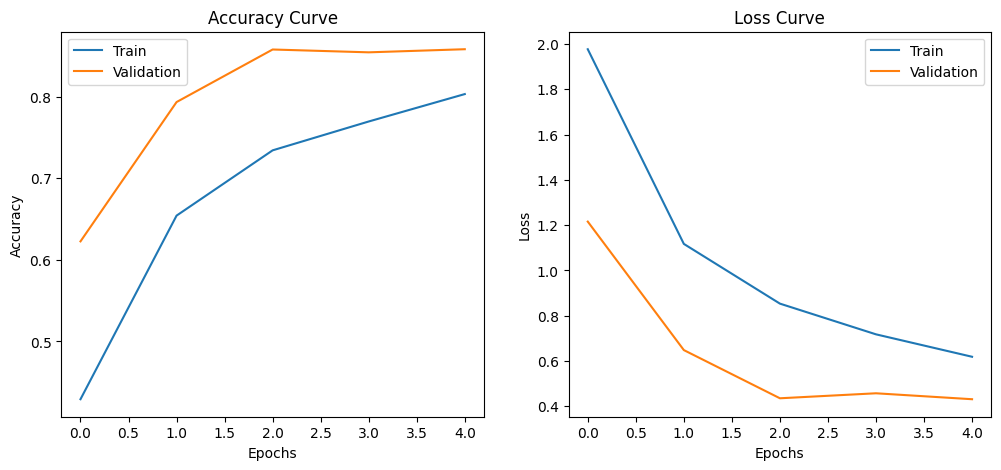

✅ Model saved in Keras format.


In [ ]:
from google.colab import drive
import zipfile
import os
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ============================================
# 1. Mount Google Drive
# ============================================
drive.mount('/content/drive')

# ============================================
# 2. Paths
# ============================================
zip_path = "/content/drive/MyDrive/archive.zip"   # dataset zip file path
extract_path = "/content/plant_disease_dataset"
checkpoint_file = "/content/best_model.keras"     # checkpoint path
train_dir = ""
valid_dir = ""

# ============================================
# 3. Unzip dataset and check structure
# ============================================
if not os.path.exists(zip_path):
    print(f"❌ Error: file not found at path: {zip_path}")
else:
    if os.path.exists(extract_path):
        shutil.rmtree(extract_path)
    os.makedirs(extract_path)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset extracted successfully.")

    # Find train and valid directories
    for root, dirs, files in os.walk(extract_path):
        if 'train' in dirs:
            train_dir = os.path.join(root, 'train')
        if 'valid' in dirs:
            valid_dir = os.path.join(root, 'valid')
        if train_dir and valid_dir:
            break

    if train_dir and valid_dir:
        print("✅ Found train and valid folders.")
        print("Number of classes:", len(os.listdir(train_dir)))
        print("Sample classes:", os.listdir(train_dir)[:10])

        # ============================================
        # 4. Data Generators (with Augmentation)
        # ============================================
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            zoom_range=0.2,
            horizontal_flip=True
        )

        valid_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(150, 150),
            batch_size=64,
            class_mode='categorical'
        )

        valid_generator = valid_datagen.flow_from_directory(
            valid_dir,
            target_size=(150, 150),
            batch_size=64,
            class_mode='categorical'
        )

        # ============================================
        # 5. CNN Model (load from checkpoint if exists)
        # ============================================
        if os.path.exists(checkpoint_file):
            print("🔄 Resuming training from saved checkpoint...")
            model = tf.keras.models.load_model(checkpoint_file)
        else:
            print("🚀 No checkpoint found, starting fresh training.")
            model = models.Sequential([
                layers.Input(shape=(150,150,3)),
                layers.Conv2D(32, (3,3), activation='relu'),
                layers.MaxPooling2D(2,2),
                layers.Conv2D(64, (3,3), activation='relu'),
                layers.MaxPooling2D(2,2),
                layers.Conv2D(128, (3,3), activation='relu'),
                layers.MaxPooling2D(2,2),
                layers.Flatten(),
                layers.Dense(128, activation='relu'),
                layers.Dropout(0.5),
                layers.Dense(train_generator.num_classes, activation='softmax')
            ])
            model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
            model.summary()

        # ============================================
        # 6. Callbacks: EarlyStopping + ModelCheckpoint
        # ============================================
        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
            ModelCheckpoint(checkpoint_file, monitor='val_accuracy', save_best_only=True)
        ]

        # ============================================
        # 7. Train the model (resume if checkpoint exists)
        # ============================================
        history = model.fit(
            train_generator,
            epochs=5,  # EarlyStopping will stop earlier if no improvement
            validation_data=valid_generator,
            callbacks=callbacks
        )

        # ============================================
        # 8. Plot training curves
        # ============================================
        plt.figure(figsize=(12,5))

        # Accuracy
        plt.subplot(1,2,1)
        plt.plot(history.history['accuracy'], label='Train')
        plt.plot(history.history['val_accuracy'], label='Validation')
        plt.title("Accuracy Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()

        # Loss
        plt.subplot(1,2,2)
        plt.plot(history.history['loss'], label='Train')
        plt.plot(history.history['val_loss'], label='Validation')
        plt.title("Loss Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()

        plt.show()

        # ============================================
        # 9. Save final model
        # ============================================
        model.save("/content/plant_disease_model_final.keras")
        print("✅ Model saved in Keras format.")
    else:
        print("❌ Error: 'train' or 'valid' folders not found inside the zip.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset extracted successfully.
✅ Found train and valid folders.
Number of classes: 38
Sample classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Peach___healthy', 'Soybean___healthy', 'Strawberry___Leaf_scorch', 'Pepper,_bell___Bacterial_spot', 'Corn_(maize)___Common_rust_', 'Apple___Cedar_apple_rust', 'Cherry_(including_sour)___healthy', 'Grape___healthy', 'Cherry_(including_sour)___Powdery_mildew']
Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
🔄 Resuming training from saved checkpoint...
Epoch 1/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 495s 446ms/step - accuracy: 0.8230 - loss: 0.5548 - val_accuracy: 0.8916 - val_loss: 0.3345
Epoch 2/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 444s 404ms/step - accuracy: 0.8394 - loss: 0.5029 - val_accuracy: 0.8994 - val_loss: 0.3019
Epoch 3/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 443s 403

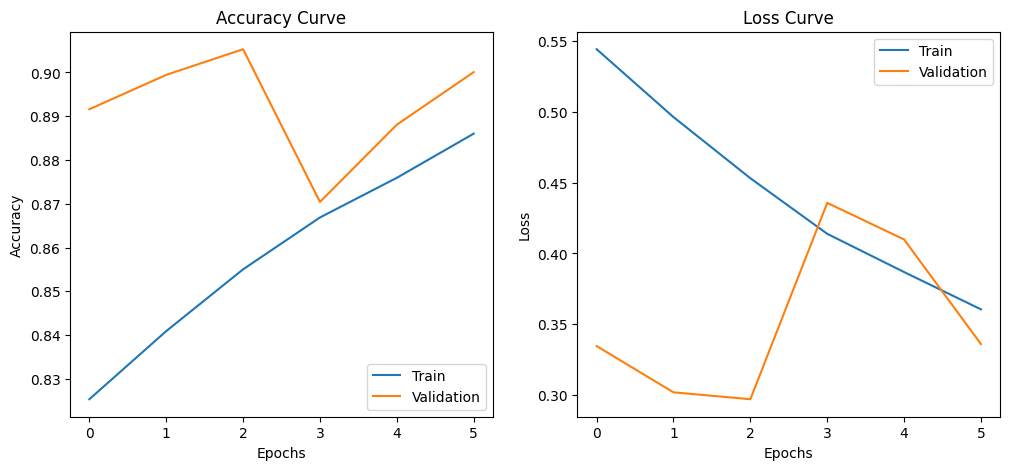

✅ Model saved in Keras format.


In [ ]:
from google.colab import drive
import zipfile
import os
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ============================================
# 1. Mount Google Drive
# ============================================
drive.mount('/content/drive')

# ============================================
# 2. Paths
# ============================================
zip_path = "/content/drive/MyDrive/archive.zip"   # dataset zip file path
extract_path = "/content/plant_disease_dataset"
checkpoint_file = "/content/best_model.keras"     # checkpoint path
train_dir = ""
valid_dir = ""

# ============================================
# 3. Unzip dataset and check structure
# ============================================
if not os.path.exists(zip_path):
    print(f"❌ Error: file not found at path: {zip_path}")
else:
    if os.path.exists(extract_path):
        shutil.rmtree(extract_path)
    os.makedirs(extract_path)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset extracted successfully.")

    # Find train and valid directories
    for root, dirs, files in os.walk(extract_path):
        if 'train' in dirs:
            train_dir = os.path.join(root, 'train')
        if 'valid' in dirs:
            valid_dir = os.path.join(root, 'valid')
        if train_dir and valid_dir:
            break

    if train_dir and valid_dir:
        print("✅ Found train and valid folders.")
        print("Number of classes:", len(os.listdir(train_dir)))
        print("Sample classes:", os.listdir(train_dir)[:10])

        # ============================================
        # 4. Data Generators (with Augmentation)
        # ============================================
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            zoom_range=0.2,
            horizontal_flip=True
        )

        valid_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(150, 150),
            batch_size=64,
            class_mode='categorical'
        )

        valid_generator = valid_datagen.flow_from_directory(
            valid_dir,
            target_size=(150, 150),
            batch_size=64,
            class_mode='categorical'
        )

        # ============================================
        # 5. CNN Model (load from checkpoint if exists)
        # ============================================
        if os.path.exists(checkpoint_file):
            print("🔄 Resuming training from saved checkpoint...")
            model = tf.keras.models.load_model(checkpoint_file)
        else:
            print("🚀 No checkpoint found, starting fresh training.")
            model = models.Sequential([
                layers.Input(shape=(150,150,3)),
                layers.Conv2D(32, (3,3), activation='relu'),
                layers.MaxPooling2D(2,2),
                layers.Conv2D(64, (3,3), activation='relu'),
                layers.MaxPooling2D(2,2),
                layers.Conv2D(128, (3,3), activation='relu'),
                layers.MaxPooling2D(2,2),
                layers.Flatten(),
                layers.Dense(128, activation='relu'),
                layers.Dropout(0.5),
                layers.Dense(train_generator.num_classes, activation='softmax')
            ])
            model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
            model.summary()

        # ============================================
        # 6. Callbacks: EarlyStopping + ModelCheckpoint
        # ============================================
        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
            ModelCheckpoint(checkpoint_file, monitor='val_accuracy', save_best_only=True)
        ]

        # ============================================
        # 7. Train the model (resume if checkpoint exists)
        # ============================================
        history = model.fit(
            train_generator,
            epochs=10,  # EarlyStopping will stop earlier if no improvement
            validation_data=valid_generator,
            callbacks=callbacks
        )

        # ============================================
        # 8. Plot training curves
        # ============================================
        plt.figure(figsize=(12,5))

        # Accuracy
        plt.subplot(1,2,1)
        plt.plot(history.history['accuracy'], label='Train')
        plt.plot(history.history['val_accuracy'], label='Validation')
        plt.title("Accuracy Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()

        # Loss
        plt.subplot(1,2,2)
        plt.plot(history.history['loss'], label='Train')
        plt.plot(history.history['val_loss'], label='Validation')
        plt.title("Loss Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()

        plt.show()

        # ============================================
        # 9. Save final model
        # ============================================
        model.save("/content/plant_disease_model_final.keras")
        print("✅ Model saved in Keras format.")
    else:
        print("❌ Error: 'train' or 'valid' folders not found inside the zip.")
